In [1]:
from PIL import Image
import torch
from diffusers import FluxFillPipeline
from diffusers.utils import load_image

from nunchaku import NunchakuFluxTransformer2dModel
from nunchaku.utils import get_precision

In [ ]:
# image = load_image("https://huggingface.co/datasets/diffusers/diffusers-images-docs/resolve/main/cup.png")
# mask = load_image("https://huggingface.co/datasets/diffusers/diffusers-images-docs/resolve/main/cup_mask.png")

precision = get_precision()  # auto-detect your precision is 'int4' or 'fp4' based on your GPU
transformer = NunchakuFluxTransformer2dModel.from_pretrained(
    f"nunchaku-tech/nunchaku-flux.1-fill-dev/svdq-int4_r32-flux.1-fill-dev.safetensors"
)
pipe = FluxFillPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-Fill-dev", transformer=transformer, torch_dtype=torch.bfloat16
).to("cuda")

  0%|          | 0/20 [00:00<?, ?it/s]

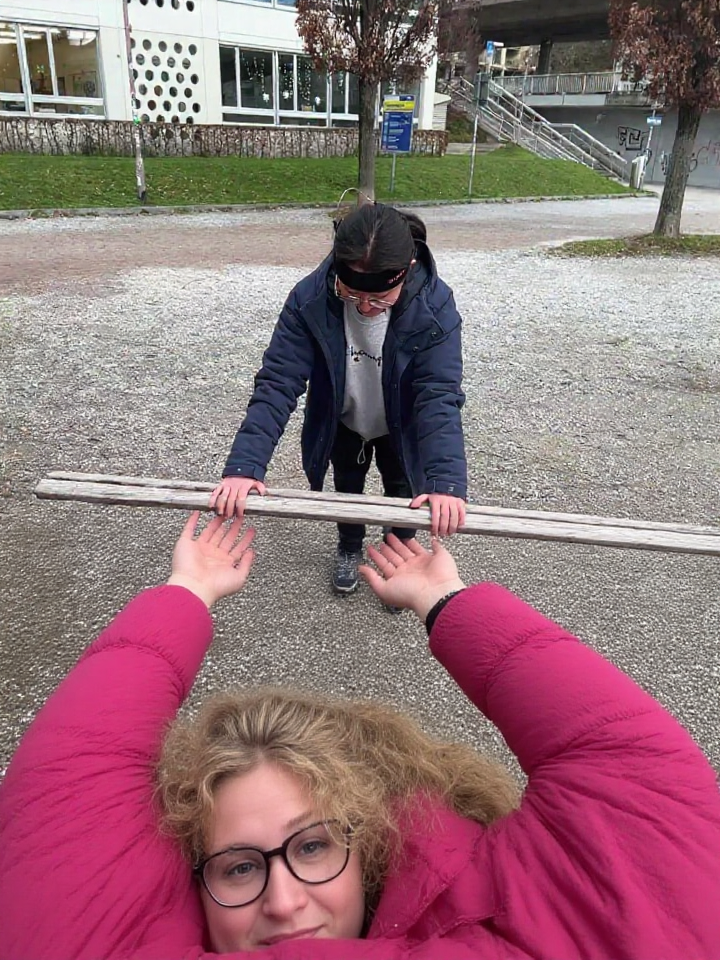

In [12]:
image = load_image("../tmp_img.png")
mask = load_image("../tmp_mask.png")

image = pipe(
    prompt="Single full body portrait photo",
    image=image,
    mask_image=mask,
    height=image.size[1] // 2,
    width=image.size[0] // 2,
    guidance_scale=30,
    num_inference_steps=20,
    max_sequence_length=512,
).images[0]
image